# LiDAR Processing with ```PDAL``` and ```Multiprocessing```

Beckett Hills, 2024


This is a guide for processing dense, large LiDAR point clouds using the ```PDAL``` python library, with a focus on raw data collected from a plane or UAS platform that has been converted from any proprietary sensor formats into an unclassified (preferably strip-aligned) ASPRS 1.4 (or 1.2) formatted ```las``` or ```laz``` file. 

Processing is separated into a few steps to facilitate use across different flight datasets that may have been generated under a wide range of conditions and mission parameters. Since current lidar sensors are increasingly powerful, and UAS platforms fly close to the ground, the output clouds are becoming extremely dense. This workflow is therefore developed to provide a starting point to quickly jump into parallel processing hundreds of small tiles using a dozen or more cores leveraging the ```Multiprocessing``` python library. This guide will work in cases using less than a dozen cores, but performace will be notably enhanced for larger point clouds when using 30 or more CPUs. (***further notes should be added on point cloud size and density later***)

The steps suggested are still very basic in order to increase efficiency and generalized success across datasets. This will hopefully provide a place to start for generating basic classified LiDAR point and surface products to be used for decisions on places to tune subsequent processing runs or generate new processing stages for analyses.

This is currently set up to handle one very large unclassified ```laz``` (or ```las``` with minor edits) as input that will be tiled, cleaned, classified, normalized (height above ground), attributes rasterized to produce DTM/DSM/CHM/Zmax, and then final output products merged into layers representing the entire, original raw input.

For now, it is also necessary to have a pre-determined grid in the ```project/shapes``` directory with the desired cell size in order to have an accurate upper left coordinates of the extent for the ```pdal tile``` function to create tiles with the expected dimensions and coverage.

The overall workflow:
1. ```runtile_clean.py```   - performs very basic outlier removal
2. ```runtile_class.py```   - classfies ground points, assigns this to the 'Z' attribute, and moves elevation to 'Z_UTM'
3. ```merge copc```         - create final merged COPC point cloud that matches original input XY extent with Z as normalized height above ground
4. ```runtile_rasters.py``` - creates quick rasters (DTM, DSM, CHM, CHMmax) for each tile
5. ```gdal_merge```         - use in-line ```bash``` command to create final raster surface 

***optional***
   
6. ```runtile_stats.py```   - adds point clouds statistical properties as attributes (eigenvalues, normals, optimalKNN, covariance)
7. ```runtile_trees.py```   - a very rudimentary R script under the hood will segment trees (developed for Longenecker - not currently very good in dense forests)

There is also a small section on visualization in jupyter (although QGIS is better).

## Setup

### Environment

***Full disclosure: at this point not all of these packages may be used anymore***

In [11]:
import os
import sys
import json
import glob
import pdal

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from osgeo import gdal,ogr

import warnings
warnings.filterwarnings('ignore')

from multiprocessing import Pool


### Edit Variables

In [60]:
# Edit these to change the date or location
flight_area = 'aspens'
flight_year = '2021'
flight_date = '0529'               # options: 0711, 0822
flight_grid = 'main'               # options: main, se, nw (for southeast flight on 0711 and northwest flight on 0822)
base_wd     = f"/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial"

number_CPU  = 39 # total CPU - 1

Z_MIN = 245
Z_MAX = 285
zlims = Z_MIN, Z_MAX

os.environ['PROJ_LIB'] = '/opt/conda/share/proj'

### Quick check

Use in-line ```bash``` to list ```ls``` the current directory and ```base_wd``` to ensure the correct locations are available. 

In [61]:
!echo "===================================================="
!echo "Notebook (Code) Dir -  contains .py and .R scripts"
!echo "===================================================="
!ls -l .

!echo "===================================================="
!echo "Base WD - contains README + code, lidar, shapes dirs"
!echo "===================================================="
!echo {base_wd}
!ls -l {base_wd}

Notebook (Code) Dir -  contains .py and .R scripts
total 3096
-rw-r--r-- 1 whills@ad.wisc.edu domain users@ad.wisc.edu 1286147 Apr 29 12:00 01-CloudRunner-Getting_Started.ipynb
-rw-r--r-- 1 whills@ad.wisc.edu domain users@ad.wisc.edu  676054 Apr 29 16:07 02-CloudRunner-Single_Tile.ipynb
-rwxr-xr-x 1 whills@ad.wisc.edu domain users@ad.wisc.edu 1197016 Apr 29 18:23 03-CloudRunner-PDAL_Multiprocessing.ipynb
Base WD - contains README + code, lidar, shapes dirs
/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial
total 2083
-rwxr-xr-x 1 whills@ad.wisc.edu domain users@ad.wisc.edu 1579701 Apr 29 12:00 01-CloudRunner-Getting_Started.slides.html
-rwxr-xr-x 1 whills@ad.wisc.edu domain users@ad.wisc.edu  971090 Apr 29 10:48 02-CloudRunner-Single_Tile.slides.html
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu       0 Apr 29 17:56 data
-rwxr-xr-x 1 whills@ad.wisc.edu domain users@ad.wisc.edu   42830 Apr 29 12:02 LiDAR_Competition_Garden.qgz


### Global Path Variables

These path variables are relative to the base working directory established above. If they are not present they will be created below. If they are present, they will NOT be overwritten.

There are many ways to nest directories for organizing flights so that it is easier for tile processing:

```
  flight_wd       = f"{lidar_dir}/{flight_date}"
  flight_wd       = f"{lidar_dir}/{flight_area}/{flight_year}/{flight_date}"
```

In [79]:
# Base directories
data_dir        = f'{base_wd}/data'
lidar_dir       = f'{data_dir}/lidar'
config_dir      = f'{data_dir}/configs'

flight_wd       = f"{lidar_dir}/{flight_date}{flight_year}"

# lidar 
las_name        = f'{flight_area}_{flight_date}{flight_year}_lidar'
base_las        = f'{flight_wd}/raw_input/{las_name}'
las_file        = f"{base_las}.las"

# I/O directories
input_dir       = f"{flight_wd}/raw_input"
output_dir      = f"{flight_wd}/merged_output"

# Process directories
tile_dir        = f"{flight_wd}/tiles"
tile_clean      = f"{flight_wd}/tiles_clean"
tile_copc       = f"{flight_wd}/tiles_copc"
tile_tree       = f"{flight_wd}/tiles_trees"
tile_stats      = f"{flight_wd}/tiles_stats"
tile_class      = f"{flight_wd}/tiles_class"
tile_raster     = f"{flight_wd}/tiles_raster"
tile_lists      = f"{flight_wd}/tiles_lists"

### Support Layers

In [80]:
# Shapes
shapes_dir      = f'{data_dir}/shp'
gridpoly_name   = "AARS_DSMGrid_50m_utm16n.geojson"
gridpoly_path   = f"{shapes_dir}/{gridpoly_name}"


### Directories

The scripts will expect these subdirectories to exit to reduce overhead during later parallel processing routines with ```Multiprocess``` and ```Pool(script.function , tile_list)```across tiled datasets.

In [82]:
!ls -lah $flight_wd

total 0
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu 0 Apr 29 18:29 .
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu 0 Apr 29 18:13 ..
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu 0 Apr 29 18:12 raw_input


In [83]:
!mkdir -v {config_dir}
!mkdir -v {output_dir}
!mkdir -v {tile_dir}
!mkdir -v {tile_clean}
!mkdir -v {tile_copc}
!mkdir -v {tile_tree}
!mkdir -v {tile_stats}
!mkdir -v {tile_class}
!mkdir -v {tile_raster}
!mkdir -v {tile_lists}

mkdir: created directory '/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/configs'
mkdir: created directory '/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/lidar/05292021/merged_output'
mkdir: created directory '/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/lidar/05292021/tiles'
mkdir: created directory '/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/lidar/05292021/tiles_clean'
mkdir: created directory '/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/lidar/05292021/tiles_copc'
mkdir: created directory '/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/lidar/05292021/tiles_trees'
mkdir: created directory '/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/lidar/05292021/tiles_stats'
mkdir: created directory '/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/lidar/05292021/tiles_class'
mkdir: created directory '/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/lidar/05292021/tiles_raster'
mkdir: created directory '/mnt/farnsworth/

In [84]:
!ls -lah $flight_wd

total 0
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu 0 Apr 29 18:30 .
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu 0 Apr 29 18:13 ..
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu 0 Apr 29 18:30 merged_output
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu 0 Apr 29 18:12 raw_input
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu 0 Apr 29 18:30 tiles
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu 0 Apr 29 18:30 tiles_class
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu 0 Apr 29 18:30 tiles_clean
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu 0 Apr 29 18:30 tiles_copc
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu 0 Apr 29 18:30 tiles_lists
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu 0 Apr 29 18:30 tiles_raster
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu 0 Apr 29 18:30 tiles_stats
drwxr-xr-x 2 whills@ad.wisc.edu domain users@ad.wisc.edu 0 Apr 29 18:30 tiles_trees


### Import Shapes

This section is only used to confirm and visualize the extent corner coordinates of the grid.

In [85]:
# INDEX FOR geojson
idx = 'id'

# READ Tiles
tile_polys = gpd.read_file(gridpoly_path,driver='GeoJSON',index=idx)
tile_polys


,id,left,top,right,bottom,bbox,geometry
0,1,311163.6206,4.798753e+06,311213.6206,4.798703e+06,None,"POLYGON ((311136.209 4798728.274, 311185.476 4..."
1,2,311163.6206,4.798703e+06,311213.6206,4.798653e+06,None,"POLYGON ((311144.736 4798679.006, 311194.004 4..."
2,3,311163.6206,4.798653e+06,311213.6206,4.798603e+06,None,"POLYGON ((311153.264 4798629.739, 311202.532 4..."
3,4,311163.6206,4.798603e+06,311213.6206,4.798553e+06,None,"POLYGON ((311161.792 4798580.471, 311211.059 4..."
4,5,311163.6206,4.798553e+06,311213.6206,4.798503e+06,None,"POLYGON ((311170.32 4798531.204, 311219.587 47..."
5,6,311163.6206,4.798503e+06,311213.6206,4.798453e+06,None,"POLYGON ((311178.847 4798481.937, 311228.115 4..."
6,7,311163.6206,4.798453e+06,311213.6206,4.798403e+06,None,"POLYGON ((311187.375 4798432.669, 311236.642 4..."
7,8,311213.6206,4.798753e+06,311263.6206,4.798703e+06,None,"POLYGON ((311185.476 4798736.801, 311234.743 4..."
8,9,311213.6206,4.798703e+06,311263.6206,4.798653e+06,None,"POLYGON ((311194.004 4798687.534, 311243.271 4..."
9,10,311213.6206,4.798653e+06,311263.6206,4.798603e+06,None,"POLYGON ((311202.532 4798638.267, 311251.799 4..."


### Plot Grid

<Axes: >

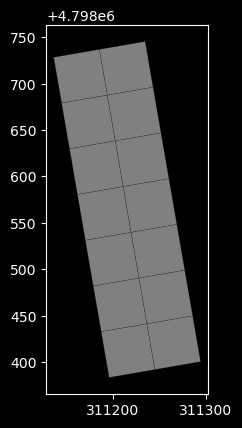

In [86]:
f, ax = plt.subplots()

tile_polys.plot(color="gray",edgecolor="black",linewidth=.1,figsize=(8,10),ax=ax)

## PDAL

### PDAL Info

In [87]:
!echo {las_file}

!pdal info -i {las_file}

/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/lidar/05292021/raw_input/aspens_05292021_lidar.las
{
  "file_size": 1225532188,
  "filename": "/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/lidar/05292021/raw_input/aspens_05292021_lidar.las",
  "now": "2025-04-29T18:31:06-0500",
  "pdal_version": "2.8.4 (git-version: 412c57)",
  "reader": "readers.las",
  "stats":
  {
    "bbox":
    {
      "EPSG:4326":
      {
        "bbox":
        {
          "maxx": -89.32639958,
          "maxy": 43.31902803,
          "maxz": 451.497,
          "minx": -89.33016909,
          "miny": 43.3134186,
          "minz": 279.14
        },
        "boundary": { "type": "Polygon", "coordinates": [ [ [ -89.329957411602692, 43.313418601846053, 279.14 ], [ -89.330169086405505, 43.31895555388602, 279.14 ], [ -89.326610936178454, 43.319028025233337, 451.497 ], [ -89.326399583890051, 43.313491059257387, 451.497 ], [ -89.329957411602692, 43.313418601846053, 279.14 ] ] ] }
      },
      "native":

### TILES

There are multiple ways to split a large cloud. 

PDAL has great utilities (e.g., )`tile` and `splitter`) that work for very large datasets that have square or rectangular bounding boxes. 

However, using these tools on smaller or irregular sites not perfectly oriented N-S or E-W isn't always ideal. For high density point clouds, this can create wasted processing time on points outside of target tiles and buffers. 

A custom function was developed to perform tiling using a set of polygons.

1. cloudrunner `cloud2Tiles`
1. PDAL `tile`
1. PDAL `splitter`



#### `cloud2tiles`

In [54]:
import sys
sys.path.append(f'/home/whills/projects/pdal_tutorial')
from cloudrunner.utils.tiling import cloud2Tiles

In [89]:
%%time

tiles = cloud2Tiles(las_file, input_poly=gridpoly_path, tile_dir=tile_dir, config_dir=config_dir, zlims=zlims, step="burntile", poly_field="id", subtractBuffer=0.0, burn=None)

Creating Tiles
Using existing directory:  /mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/lidar/05292021/tiles
File Type : geojson
 -> Output Tile Feature Path :  /mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/lidar/05292021/tiles/AARS_DSMGrid_50m_utm16n_buff_0_id_1.geojson
 -> Output Buffer Feature Path :  /mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/lidar/05292021/tiles/AARS_DSMGrid_50m_utm16n_buff_30_id_1.geojson
 -> Output Union Feature Path :  /mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/lidar/05292021/tiles/AARS_DSMGrid_50m_utm16n_union_30m_id_1.geojson
 -> Output Tile Feature Path :  /mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/lidar/05292021/tiles/AARS_DSMGrid_50m_utm16n_buff_0_id_2.geojson
 -> Output Buffer Feature Path :  /mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/lidar/05292021/tiles/AARS_DSMGrid_50m_utm16n_buff_30_id_2.geojson
 -> Output Union Feature Path :  /mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/lida

#### PDAL Tile
Using the ```pdal tile``` command line function is very fast and preferred to help align tiles with a square grid. 

### PDAL Splitter

A secondary function that will also easily run with python scripts is ```splitter```. This will not strictly produce square tiles.

***The ```splitter``` notebook cell block is currently set to 'Raw' to exclude it from calculations***

## PDAL with ```Multiprocessing``` and ```Pool()```

### Prep for ```Pool()```

#### ```glob``` tiles

In [14]:
tiles = glob.glob(f"{tile_dir}/*.laz")
tiles

['/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_6_-19.laz',
 '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_12_-7.laz',
 '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_15_-9.laz',
 '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_12_-8.laz',
 '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_8_-21.laz',
 '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_3_-13.laz',
 '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_3_-15.laz',
 '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_9_-12.laz',
 '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/Lake

#### Cull tiles

Tiles with a point count below a threshold can be moved into a separate directory ```tiles_delete``` that will not be included in further calculations. This step does not actually delete any files, only moves them to a different folder.

In [15]:
%%time
point_threshold=10000
delete_tiles = []

delete_dir = f"{os.path.dirname(lidar_file)}/tiles_delete"
!mkdir {delete_dir}

for tile in tiles:
    # Check for points in the tile
    reader = pdal.Reader.las(tile).pipeline()
    
    reader.execute()
    metadata = reader.metadata
    pt_ct = reader.execute()
    if pt_ct < point_threshold:
        print(f"{pt_ct} points  --  {tile}")
        delete_tiles.append(tile)
        !mv {tile} {delete_dir}/
len(delete_tiles)

mkdir: cannot create directory ‘/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/raw_input/tiles_delete’: File exists
30 points  --  /home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_13_-20.laz
5 points  --  /home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_13_-15.laz
2993 points  --  /home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_6_-20.laz
5691 points  --  /home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_6_-10.laz
2744 points  --  /home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_13_-16.laz
915 points  --  /home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_21_-2.laz
881 points  --  /home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/Lakeshor

46

### Run Tiles with ```Pool()```

#### Clean

In [16]:
%%time
import os
import glob
from multiprocessing import Process, Queue, Pool

import runtile_clean

tiles_list = glob.glob(f"{tile_dir}/*.laz")
tiles_list.sort()
print(f"File count {len(tiles_list)} \n Tiles: {tiles_list}")

if __name__ == '__main__':
    with Pool(processes=number_CPU, maxtasksperchild=1) as p:
        p.map(runtile_clean.runtile_clean, tiles_list)

File count 180 
 Tiles: ['/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_0_-15.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_0_-16.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_0_-17.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_10_-10.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_10_-11.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_10_-12.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_10_-13.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles/LakeshorePreserve_20240711_10_-14.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve

#### Classify

In [17]:
%%time
import os
import glob
from multiprocessing import Process, Queue, Pool

import runtile_classify

tiles_list = glob.glob(f"{tile_clean}/*_cln.laz")
tiles_list.sort()
print(f"File count {len(tiles_list)} \n Tiles: {tiles_list}")


if __name__ == '__main__':
    with Pool(processes=number_CPU, maxtasksperchild=1) as p:
        p.map(runtile_classify.runtile_classify, tiles_list)

File count 180 
 Tiles: ['/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_clean/LakeshorePreserve_20240711_0_-15_301990_4772934_cln.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_clean/LakeshorePreserve_20240711_0_-16_301972_4772904_cln.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_clean/LakeshorePreserve_20240711_0_-17_301978_4772844_cln.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_clean/LakeshorePreserve_20240711_10_-10_302527_4773264_cln.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_clean/LakeshorePreserve_20240711_10_-11_302527_4773204_cln.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_clean/LakeshorePreserve_20240711_10_-12_302527_4773144_cln.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_clean/LakeshorePreserve_20240711_10_-13_302527_4773084_cln.laz'

#### Merge into Final COPC

In [18]:
%%time

# NOTE this uses number_CPU

# Variables & Paths
# -----------------------
step="stats"

#tile_names = glob.glob(os.path.join(tile_dir,"*"+step+".copc.laz"))
#tile_list = glob.glob(f"{tile_copc}/*_stats.copc.laz")

tiles_list = glob.glob(f"{tile_class}/*_grnd_hag.laz")
tiles_list.sort()

# this is a KEY detail for looping tile list 
# to get the string correctly formatted in the JSON below
outputs = ""
for t in tiles_list:
    outputs += '"' + t + '",'

# Check expected counts
print(f"File count {len(tiles_list)} \n Tiles: {tiles_list}")

copcname = os.path.basename(f"{lidar_file}_cln_grnd_hag.copc.laz")

outcopc = f"{output_dir}/{copcname}"

# Main pdal command list as a string
# -----------------------
pdal_json_merge = '[' + outputs + '{"type": "filters.merge"},{"type": "writers.copc", "filename":"' + outcopc + '", "threads":"' + str(number_CPU) + '", "forward": "all", "extra_dims": "all", "pipeline":"true" } ]'
pdal_json_merge

# Create a JSON of the command string
# -----------------------
print("JSON merge :\n",pdal_json_merge)

pdal_json_merge_file = f"{output_dir}/{lidar_basename}_copc.json"

with open(pdal_json_merge_file, "w") as outjson:
    json.dump(pdal_json_merge, outjson,indent=4,skipkeys=True, ensure_ascii = False)

# Execute PDAL pipeline
# -----------------------
pipeline = pdal.Pipeline(json.dumps(json.loads(pdal_json_merge)))
pipeline.execute() # run the pipeline


File count 180 
 Tiles: ['/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_class/LakeshorePreserve_20240711_0_-15_301990_4772934_cln_grnd_hag.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_class/LakeshorePreserve_20240711_0_-16_301972_4772904_cln_grnd_hag.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_class/LakeshorePreserve_20240711_0_-17_301978_4772844_cln_grnd_hag.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_class/LakeshorePreserve_20240711_10_-10_302527_4773264_cln_grnd_hag.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_class/LakeshorePreserve_20240711_10_-11_302527_4773204_cln_grnd_hag.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_class/LakeshorePreserve_20240711_10_-12_302527_4773144_cln_grnd_hag.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_class/Lak

181887192

#### Rasters

In [19]:
%%time
import os
import glob
from multiprocessing import Process, Queue, Pool

import runtile_rasters_basics

#tile_list = glob.glob(f"{tile_stats}/*_stats.laz")
tiles_list = glob.glob(f"{tile_class}/*_grnd_hag.laz")
tiles_list.sort()
print(f"File count {len(tiles_list)} \n Tiles: {tiles_list}")


if __name__ == '__main__':
    with Pool(processes=39) as p:
        p.map(runtile_rasters_basics.runtile_rasters_basics, tiles_list)


File count 180 
 Tiles: ['/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_class/LakeshorePreserve_20240711_0_-15_301990_4772934_cln_grnd_hag.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_class/LakeshorePreserve_20240711_0_-16_301972_4772904_cln_grnd_hag.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_class/LakeshorePreserve_20240711_0_-17_301978_4772844_cln_grnd_hag.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_class/LakeshorePreserve_20240711_10_-10_302527_4773264_cln_grnd_hag.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_class/LakeshorePreserve_20240711_10_-11_302527_4773204_cln_grnd_hag.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_class/LakeshorePreserve_20240711_10_-12_302527_4773144_cln_grnd_hag.laz', '/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_class/Lak

#### Merge Raster Tiles

In [20]:
listname = os.path.basename(lidar_file)

!echo {tile_lists}
!ls {tile_raster}/*_dtm_mean_1m > {tile_lists}/{listname}_DTM_list.txt
!ls {tile_raster}/*_dsm_idw_20cm > {tile_lists}/{listname}_DSM_list.txt
!ls {tile_raster}/*_chm_idw_20cm > {tile_lists}/{listname}_CHM_list.txt
!ls {tile_raster}/*_z_max_20cm > {tile_lists}/{listname}_Zmax_list.txt
!ls {tile_raster}/*_density_count_1m > {tile_lists}/{listname}_Density_list.txt
!echo "Done"

/home/beckett/Desktop/cloudrunner/lidar/LakeshorePreserve/2024/0711/tiles_lists
Done


In [21]:
%%time

surfaces = [ "DTM" , "DSM" ,  "CHM", "Zmax" , "Density"]

for surface in surfaces:
    output_name = f"{output_dir}/{os.path.basename(lidar_file)}_{surface}"
    list_name = f"{tile_lists}/{os.path.basename(lidar_file)}_{surface}_list.txt"
    if surface == "Density":
        !gdal_merge.py -of ENVI -ot float32 -ps .2 .2 -init -9999 -n 0 -a_nodata -9999 -o {output_name} --optfile {list_name}
    else:
        !gdal_merge.py -of ENVI -ot float32 -ps .2 .2 -init -9999 -a_nodata -9999 -o {output_name} --optfile {list_name}


0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
CPU times: user 352 ms, sys: 1.1 s, total: 1.45 s
Wall time: 12 s


In [22]:
print("Done")

Done


## Post-Processing

This will calculate point cloud statistics using built-in ```PDAL``` functions that can be found [here](https://pdal.io/en/latest/stages/filters.html#pointwise-features).

**BEWARE** this step can take several hours to complete across hundreds of tiles.

```runtile_stats``` calculates the following:

```
    # STATS #
    optKNN  = pdal.Filter.optimalneighborhood(min_k=8,max_k=250)
    eigen   = pdal.Filter.eigenvalues(knn=50,normalize=True)
    covar   = pdal.Filter.covariancefeatures(knn=50, threads=10,optimized=True,feature_set="all",mode="Normalized")
    normals = pdal.Filter.normal(knn=8,refine=True)
    radials = pdal.Filter.radialdensity(radius=.5)
```

### Stats

In [9]:
%%time
import os
import glob
from multiprocessing import Process, Queue, Pool

import runtile_stats


#tile_list = glob.glob(f"{tile_tree}/*_tree-seg-w.laz")
tiles_list = glob.glob(f"{tile_class}/*_grnd_hag.laz")
tiles_list.sort()
print(f"File count {len(tiles_list)} \n Tiles: {tiles_list}")


if __name__ == '__main__':
    with Pool(processes=38) as p:
        p.map(runtile_stats.runtile_stats, tiles_list)



File count 400 
 Tiles: ['/home/beckett/Desktop/LakeshorePreserve/lidar/2024/0822/tiles_class/LakeshorePreserve_20240822_0_-19_300963_4772904_cln_grnd_hag.laz', '/home/beckett/Desktop/LakeshorePreserve/lidar/2024/0822/tiles_class/LakeshorePreserve_20240822_0_-20_300950_4772844_cln_grnd_hag.laz', '/home/beckett/Desktop/LakeshorePreserve/lidar/2024/0822/tiles_class/LakeshorePreserve_20240822_0_-21_300946_4772784_cln_grnd_hag.laz', '/home/beckett/Desktop/LakeshorePreserve/lidar/2024/0822/tiles_class/LakeshorePreserve_20240822_10_-10_301507_4773444_cln_grnd_hag.laz', '/home/beckett/Desktop/LakeshorePreserve/lidar/2024/0822/tiles_class/LakeshorePreserve_20240822_10_-11_301507_4773384_cln_grnd_hag.laz', '/home/beckett/Desktop/LakeshorePreserve/lidar/2024/0822/tiles_class/LakeshorePreserve_20240822_10_-12_301507_4773324_cln_grnd_hag.laz', '/home/beckett/Desktop/LakeshorePreserve/lidar/2024/0822/tiles_class/LakeshorePreserve_20240822_10_-13_301507_4773264_cln_grnd_hag.laz', '/home/beckett/Desk

### Point Cloud Vizualization

QGIS is an excellent way to vizualize ```.copc.laz``` files (COPC), and will even convert a ```laz``` file to the COPC format on-the-fly when loaded into the map document, so plotting in jupyter often isn't as necessary. This is included for a complete guide to processing LiDAR in jupyter using ```PDAL``` and ```Multiprocessing``` libraries.

NOTE: The packages and supporting dependencies needed for this section ```geemap```, ```laspy```, or ```open3d``` were not a part of the suggested environment to get up and running.

#### GEE Map

#### Laspy & Open3d

### Trees

This function runs a R script to create segmentation. It was created for Longenecker Gardens and may not perform in dense forest.

NOTE: To be run in jupyter, this section requires R and other supporting libraries for R and python (e.g., ```sklearn```) that were not a part of the suggested environment to get up and running.

The code below is a selection of lines that outline a way to erode the areas between segments to create a polygon layer that closer matches the target area for delineation.

In [10]:
print("Notebook finished.")

Notebook finished.
